In [3]:
import os
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point

In [4]:
# Disable osmnx HTTP cache — no notebooks/cache/ directory created.
# Graph is persisted to data/interim/ so subsequent runs skip the download.
# Delete sd_walk_graph.graphml manually if you need to re-download (e.g. after changing place name).
ox.settings.use_cache = False

_graphml_path = "../data/processed/sd_walk_graph.graphml"

if os.path.exists(_graphml_path):
    G = ox.load_graphml(_graphml_path)
else:
    G = ox.graph_from_place("San Diego, CA, USA", network_type="walk")
    ox.save_graphml(G, _graphml_path)

edges = ox.graph_to_gdfs(G, nodes=False)
print(f"CRS:         {edges.crs}")
print(f"Total edges: {len(edges):,}")
print(f"Bounds:      {edges.total_bounds}")

CRS:         epsg:4326
Total edges: 684,012
Bounds:      [-117.324036    32.5339564 -116.9075593   33.1144246]


In [5]:
# load in the crime, walkability, and light data
crime_gdf = gpd.read_file("../data/processed/crime_final_gdf.gpkg")
walkability_gdf = gpd.read_file("../data/processed/walkability_final_gdf.gpkg")
light_gdf = gpd.read_file("../data/processed/streetlights/streetlights_processed.geojson")

display(crime_gdf.head())
display(walkability_gdf.head())
display(light_gdf.head())


crime_gdf.describe()

,INCIDENT_NUM,DATE_TIME,DAY_OF_WEEK,ADDRESS_ROAD_PRIMARY,CALL_TYPE,DISPOSITION,PRIORITY,HOUR,geometry
0,E26040027846,2026-04-20 10:48:53,2.0,EL CAJON,415V,R,1.0,10,POINT (-117.06696 32.76148)
1,E26040027876,2026-04-20 11:07:54,2.0,C,242,R,1.0,11,POINT (-117.16002 32.71684)
2,E26040027882,2026-04-20 11:10:22,2.0,HOTEL CIRCLE SOUTH,415V,R,1.0,11,POINT (-117.17811 32.7589)
3,E26040027891,2026-04-20 11:15:24,2.0,LANDIS,242R,R,2.0,11,POINT (-117.12218 32.74549)
4,E26040028068,2026-04-20 13:20:46,2.0,AIR,415V,O,1.0,13,POINT (-117.09512 32.71952)


,GEOID,CBSA,CBSA_Name,TotPop,NatWalkInd,geometry
0,060730027122,41740.0,"San Diego-Chula Vista-Carlsbad, CA",1653,13.500000,"POLYGON ((-117.08306 32.72588, -117.0828 32.72..."
1,060730186012,41740.0,"San Diego-Chula Vista-Carlsbad, CA",3958,5.333333,"POLYGON ((-117.35296 33.22489, -117.35294 33.2..."
2,060730186093,41740.0,"San Diego-Chula Vista-Carlsbad, CA",2376,13.000000,"POLYGON ((-117.31819 33.25084, -117.31819 33.2..."
3,060730194063,41740.0,"San Diego-Chula Vista-Carlsbad, CA",1485,6.500000,"POLYGON ((-117.2737 33.19762, -117.27367 33.19..."
4,060730195032,41740.0,"San Diego-Chula Vista-Carlsbad, CA",1079,16.333333,"POLYGON ((-117.24344 33.20156, -117.24329 33.2..."


,sap_obj_nr,status,mapng_stat_cd,drawing_date,dup_sapobjnr_flag,data_quality_flag,geometry
0,IF?0100000000000243406,A,AB,None,0,ok,POINT (-117.23655 32.76638)
1,IF?0100000000000239557,A,AB,None,0,ok,POINT (-117.1539 32.72578)
2,IF?0100000000000243586,A,AB,None,0,ok,POINT (-117.23572 32.76619)
3,IF?0100000000000238417,A,AB,None,0,ok,POINT (-117.1091 32.71928)
4,IF?0100000000000238529,A,AB,None,0,ok,POINT (-117.10915 32.71963)


,DATE_TIME,DAY_OF_WEEK,PRIORITY,HOUR
count,45742,45742.000000,45742.000000,45742.000000
mean,2024-12-08 14:54:09.771000,3.993551,1.140877,12.945214
min,2024-01-01 00:08:14,1.000000,0.000000,0.000000
25%,2024-05-25 19:12:29.500000,2.000000,1.000000,9.000000
50%,2024-10-11 09:28:37,4.000000,1.000000,14.000000
75%,2025-06-20 05:17:35.750000,6.000000,1.000000,18.000000
max,2026-04-23 21:35:02,7.000000,9.000000,23.000000
std,NaN,2.024581,1.131213,6.466463


## Crime Scoring — Score Reference & Reasoning

Each crime row gets one `severity_score` based on its call type. The score bakes in two things together: **how serious is this crime** (FBI UCR hierarchy) and **how directly does it affect someone walking nearby** (pedestrian exposure). Both inform the single number — high seriousness + high exposure = 3.0; low seriousness + low exposure = 0.4.

**Score range:** 0.4 (lowest pedestrian risk) → 3.0 (maximum pedestrian danger)

---

### Score 3.0 — Maximum danger: direct lethal or predatory threat to a person on foot

**HOMICIDE**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `187` | Murder | Highest-severity crime possible. A confirmed murder nearby signals a lethal threat that has already materialized. Direct exposure — anyone in the vicinity is at risk from an offender who has demonstrated willingness to kill. |
| `187-SUSP` | Murder suspect at scene | Suspect still present at or near a murder scene. Active, armed, already proven lethal. Maximum score regardless of time of day. |

**KIDNAPPING**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `207` | Kidnapping in progress | Active predatory abduction of a person. The offender is physically targeting individuals on foot or nearby. Highest FBI tier, maximum direct pedestrian exposure. |
| `207R` | Kidnapping report | Predatory offender confirmed operating in this corridor. A pedestrian walking the same route faces demonstrated risk of targeted attack. |

**ASSAULT WITH DEADLY WEAPON**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `245` | ADW in progress | Active weapon assault on a person. Attacker is armed and already using a weapon — immediate lethal threat to any pedestrian in range. |
| `245-SUSP` | ADW suspect at scene | Armed suspect confirmed at scene of a weapon assault. |
| `245DV` | ADW domestic violence | Weapon assault in a domestic violence context — active scene, attacker potentially still present. |
| `245R` | ADW report | Pattern signal: a weapon assault happened in this corridor. Demonstrates the area has seen lethal-force incidents. |
| `417` | Threatening with weapon | Person actively threatening others with a weapon. Immediate danger to any pedestrian nearby. |
| `417R` | Threatening with weapon report | Recent weapon threat in this corridor — attacker not yet apprehended. |

**ROBBERY**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `211` | Robbery in progress | Active robbery — offender is using force or threat against victims right now. Direct, targeted threat to pedestrians. |
| `211-SUSP` | Robbery suspect at scene | Suspect still on scene of an active robbery. Extreme pedestrian exposure. |
| `211R` | Robbery report | Confirmed robbery pattern in this corridor. Pedestrians are the target. |
| `211C` | Robbery caser | Offender observed casing for robbery — pre-crime indicator of active targeting in this area. |

---

### Score 2.8 — High danger: targeted vehicle theft with potential violence

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `215` | Car jacking in progress | Active car jacking — attacker confronted the victim in a vehicle. High violence potential, pedestrians nearby are in the threat zone. |
| `215R` | Car jacking report | Confirmed carjacking in this corridor. Lower than in-progress but still a high pedestrian risk signal. |

---

### Score 2.4 — Significant danger: lethal force deployed or threatened at area level

**FIREARMS DISCHARGE**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `246` | Firing at occupied house/vehicle | Shots fired at an occupied structure or vehicle — bullets are moving through the public space a pedestrian would occupy. |
| `246R` | Firing at occupied house/vehicle report | Confirmed shooting incident in this corridor. Active shooter pattern in the area. |
| `247` | Firing at unoccupied vehicle | Shots fired at property — less immediately lethal than `246` but live rounds were discharged in the area. |
| `247R` | Firing at unoccupied vehicle report | Pattern of live-fire incidents in this corridor. |
| `11-6` | Discharging firearms | Shots fired in the area — any pedestrian in the corridor is in the trajectory zone. |
| `11-6SPT` | ShotSpotter activation | Acoustic gunshot detection confirmation. Shots fired, precise location confirmed by sensor. |

**BOMB / EXPLOSION**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `EXPLO` | Explosion | An explosion has occurred — immediate danger to anyone in the area. |
| `ALERT4` | Bomb/hijack threat | Confirmed credible bomb or hijack threat. Law enforcement response, area cordoned. |
| `BOMB` | Bomb threat | Active bomb threat at a location in this corridor. |
| `BOMB-S` | Bomb threat (school) | School-located bomb threat — area likely under evacuation, elevated pedestrian/civilian exposure. |

---

### Score 2.0 — Moderate-high danger: direct physical assault or credible personal threats

**BATTERY**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `242` | Battery in progress | Physical assault actively occurring. The attacker is already using force against a person. |
| `242R` | Battery report | Confirmed physical assault in this corridor. Pattern signal for pedestrian risk. |

**THREATS / STALKING**
| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `422` | Criminal threats | Explicit criminal threat against a person — escalation to violence is credible. |
| `422R` | Criminal threats report | Documented criminal threat in this area. |
| `136` | Intimidation of witness | Witness intimidation — organized threat activity operating in this corridor. |
| `646` | Stalking | Active stalking — targeted predatory behavior against a specific person in this area. |
| `646R` | Stalking report | Documented stalking pattern in this corridor. |
| `653M` | Threatening phone call report | Credible threat made by phone — attacker has identified a target in this area. |
| `415W` | Disturbing peace with unconcealed weapon | Person carrying a weapon visibly in public — immediate intimidation threat to pedestrians nearby. |

---

### Score 1.6 — Moderate danger: escalating situation or violent disturbance

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `415V` | Disturbing peace with violence | Active violent disturbance — physical altercation in a public area, pedestrians nearby are at risk. |
| `415DV` | Domestic violence occurring now | Active domestic violence incident — volatile, often escalates, anyone nearby is in the danger zone. |
| `5150V` | Mental case — violent or urgent | Violent psychiatric crisis. Person is in active distress and has been violent or is imminently likely to be. |
| `FP` | Foot pursuit | Police foot pursuit underway — suspect is fleeing through pedestrian areas. |
| `ESCAPE` | Escape / escapee | A person has escaped from custody. Apprehension in progress, may pass through pedestrian corridors. |

---

### Score 1.2 — Lower-moderate: property crime with some pedestrian exposure

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `451` | Arson in progress | Active fire-setting — immediate hazard to anyone in the area. |
| `451R` | Arson report | Confirmed arson in this corridor — fire hazard and pattern indicator. |

---

### Score 0.8 — Low-moderate: opportunistic entry crime

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `459HP` | Burglary hot prowl | Burglar entered an occupied residence — high aggression indicator, offender willing to confront occupants. Moderate pedestrian exposure. |

---

### Score 0.6 — Low: property or area concern, indirect pedestrian risk

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `459` | Burglary in progress | Active break-in underway — offender present, may encounter pedestrians. |
| `459-SUSP` | Burglary suspect at scene | Burglary suspect still on scene. Property crime but offender is nearby. |
| `11-7` | Prowler | Person prowling — potential precursor to break-in or assault. Low but real pedestrian exposure. |
| `CCW` | Carrying concealed weapon | Person confirmed carrying a concealed weapon — indirect threat. Not active, but a signal of armed presence. |
| `NARC` | Narcotics activity | Drug activity in the area — correlates with other violent crime. Indirect pedestrian exposure. |
| `647F` | Drunk/drugs in public | Intoxicated person in public — unpredictable behavior, low but real risk to passersby. |
| `HATEINV` | Hate crime investigation | Hate crime confirmed in this corridor — targeted aggression toward specific groups. |
| `AUHATE` | Hate incident all units | Active hate incident with all-units notification — broader area under advisory. |
| `HZRD` | Hazardous condition | General hazard — chemical spill, structural, or similar. Not violent but real danger to pedestrians. |
| `1155` | Hazardous/chemical spill | Chemical spill — evacuate the area, pedestrian exposure to toxic hazard. |

---

### Score 0.4 — Minimal: low pedestrian exposure, background environment indicator

| Call type | Description | Reasoning |
|-----------|-------------|-----------|
| `602` | Trespassing | Unauthorized presence — lowest active threat to pedestrians. Background indicator of area quality. |
| `314` | Indecent exposure | Public indecency — low physical danger but discomfort signal for pedestrian experience. |
| `314R` | Indecent exposure report | Documented indecency pattern in this corridor. |
| `ANIMAL` | Vicious animal | Potentially dangerous animal — real but low-probability threat to a pedestrian walking by. |


In [95]:
# ── SEVERITY_MAP ──────────────────────────────────────────────────────────
# Maps each SDPD call type to (crime_category, severity_score).
#
# Each score bakes in both crime severity (FBI UCR hierarchy) and how directly
# a pedestrian is exposed to the threat. See markdown cell above for full
# per-call-type reasoning.
#
# Source: docs/references/pd_cfs_calltypes_datasd.csv

SEVERITY_MAP = {
    # ── HOMICIDE  [Score 3.0] ──────────────────────────────────────────────
    "187":       ("HOMICIDE",             3.0),
    "187-SUSP":  ("HOMICIDE",             3.0),

    # ── KIDNAPPING  [Score 3.0] ────────────────────────────────────────────
    "207":       ("KIDNAPPING",           3.0),
    "207R":      ("KIDNAPPING",           3.0),

    # ── ASSAULT WITH WEAPON  [Score 3.0] ──────────────────────────────────
    "245":       ("ASSAULT_WITH_WEAPON",  3.0),
    "245-SUSP":  ("ASSAULT_WITH_WEAPON",  3.0),
    "245DV":     ("ASSAULT_WITH_WEAPON",  3.0),
    "245R":      ("ASSAULT_WITH_WEAPON",  3.0),
    "417":       ("ASSAULT_WITH_WEAPON",  3.0),
    "417R":      ("ASSAULT_WITH_WEAPON",  3.0),

    # ── ROBBERY  [Score 3.0] ───────────────────────────────────────────────
    "211":       ("ROBBERY",              3.0),
    "211-SUSP":  ("ROBBERY",             3.0),
    "211R":      ("ROBBERY",              3.0),
    "211C":      ("ROBBERY",              3.0),

    # ── CARJACKING  [Score 2.8] ────────────────────────────────────────────
    "215":       ("CARJACKING",           2.8),
    "215R":      ("CARJACKING",           2.8),

    # ── FIREARMS DISCHARGE  [Score 2.4] ───────────────────────────────────
    "246":       ("FIREARMS_DISCHARGE",   2.4),
    "246R":      ("FIREARMS_DISCHARGE",   2.4),
    "247":       ("FIREARMS_DISCHARGE",   2.4),
    "247R":      ("FIREARMS_DISCHARGE",   2.4),
    "11-6":      ("FIREARMS_DISCHARGE",   2.4),
    "11-6SPT":   ("FIREARMS_DISCHARGE",   2.4),

    # ── BOMB / EXPLOSION  [Score 2.4] ─────────────────────────────────────
    "EXPLO":     ("BOMB_EXPLOSION",       2.4),
    "ALERT4":    ("BOMB_EXPLOSION",       2.4),
    "BOMB":      ("BOMB_EXPLOSION",       2.4),
    "BOMB-S":    ("BOMB_EXPLOSION",       2.4),

    # ── BATTERY  [Score 2.0] ───────────────────────────────────────────────
    "242":       ("BATTERY",              2.0),
    "242R":      ("BATTERY",              2.0),

    # ── THREATS / STALKING  [Score 2.0] ───────────────────────────────────
    "422":       ("THREATS_STALKING",     2.0),
    "422R":      ("THREATS_STALKING",     2.0),
    "136":       ("THREATS_STALKING",     2.0),
    "646":       ("THREATS_STALKING",     2.0),
    "646R":      ("THREATS_STALKING",     2.0),
    "653M":      ("THREATS_STALKING",     2.0),
    "415W":      ("THREATS_STALKING",     2.0),

    # ── VIOLENT DISTURBANCE  [Score 1.6] ──────────────────────────────────
    "415V":      ("VIOLENT_DISTURBANCE",  1.6),
    "415DV":     ("VIOLENT_DISTURBANCE",  1.6),
    "5150V":     ("VIOLENT_DISTURBANCE",  1.6),
    "FP":        ("VIOLENT_DISTURBANCE",  1.6),
    "ESCAPE":    ("VIOLENT_DISTURBANCE",  1.6),

    # ── ARSON  [Score 1.2] ─────────────────────────────────────────────────
    "451":       ("ARSON_BURGLARY",       1.2),
    "451R":      ("ARSON_BURGLARY",       1.2),

    # ── BURGLARY HOT PROWL  [Score 0.8] ───────────────────────────────────
    "459HP":     ("ARSON_BURGLARY",       0.8),

    # ── BURGLARY IN PROGRESS  [Score 0.6] ─────────────────────────────────
    "459":       ("ARSON_BURGLARY",       0.6),
    "459-SUSP":  ("ARSON_BURGLARY",       0.6),

    # ── AREA SAFETY  [Score 0.6] ───────────────────────────────────────────
    "11-7":      ("AREA_SAFETY",          0.6),
    "CCW":       ("AREA_SAFETY",          0.6),
    "NARC":      ("AREA_SAFETY",          0.6),
    "647F":      ("AREA_SAFETY",          0.6),
    "HATEINV":   ("AREA_SAFETY",          0.6),
    "AUHATE":    ("AREA_SAFETY",          0.6),
    "HZRD":      ("AREA_SAFETY",          0.6),
    "1155":      ("AREA_SAFETY",          0.6),
    "602":       ("AREA_SAFETY",          0.4),

    # ── PUBLIC NUISANCE  [Score 0.4] ──────────────────────────────────────
    "314":       ("PUBLIC_NUISANCE",      0.4),
    "314R":      ("PUBLIC_NUISANCE",      0.4),
    "ANIMAL":    ("PUBLIC_NUISANCE",      0.4),
}

# ── Time-of-day multipliers ────────────────────────────────────────────────
# Keyed by crime_category. Categories not listed default to 1.0 (no adjustment).

NIGHT_MULTIPLIER = {
    "ROBBERY":             1.3,
    "ASSAULT_WITH_WEAPON": 1.3,
    "BATTERY":             1.2,
    "THREATS_STALKING":    1.2,
    "VIOLENT_DISTURBANCE": 1.2,
    "KIDNAPPING":          1.15,
    "AREA_SAFETY":         1.15,
    "PUBLIC_NUISANCE":     1.1,
}

DAY_MULTIPLIER = {
    "ROBBERY":        1.1,
    "ARSON_BURGLARY": 1.1,
}

In [96]:
# ── Feature engineering: severity_score, time_multiplier, combined_weight ─

_default = ("UNKNOWN", 0.4)  # fallback: lowest pedestrian exposure score

crime_gdf["crime_category"] = crime_gdf["CALL_TYPE"].map(
    lambda c: SEVERITY_MAP.get(c, _default)[0]
)
crime_gdf["severity_score"] = crime_gdf["CALL_TYPE"].map(
    lambda c: SEVERITY_MAP.get(c, _default)[1]
)

# Classify each incident by actual hour of occurrence
crime_gdf["time_of_day"] = np.where(crime_gdf["HOUR"].between(6, 20), "day", "night")

# Look up the per-category multiplier for the actual time this crime occurred
crime_gdf["time_multiplier"] = np.where(
    crime_gdf["time_of_day"] == "night",
    crime_gdf["crime_category"].map(NIGHT_MULTIPLIER).fillna(1.0),
    crime_gdf["crime_category"].map(DAY_MULTIPLIER).fillna(1.0),
)

# Final weight — not capped; normalization happens at the edge-score aggregation step
crime_gdf["combined_weight"] = crime_gdf["severity_score"] * crime_gdf["time_multiplier"]

# Split for spatial join step
crimes_day   = crime_gdf[crime_gdf["time_of_day"] == "day"]
crimes_night = crime_gdf[crime_gdf["time_of_day"] == "night"]

# Sanity checks
unmapped = crime_gdf.loc[crime_gdf["crime_category"] == "UNKNOWN", "CALL_TYPE"].unique().tolist()
print(f"Total: {len(crime_gdf):,}  |  Day: {len(crimes_day):,}  |  Night: {len(crimes_night):,}")
print(f"Unmapped call types: {unmapped if unmapped else 'none'}")

Total: 45,742  |  Day: 32,660  |  Night: 13,082
Unmapped call types: none


In [97]:
cols = ["CALL_TYPE", "crime_category", "time_of_day", "severity_score", "time_multiplier", "combined_weight"]
print(crime_gdf[cols].sample(10, random_state=42).to_string(index=False))
print()
print(crime_gdf["combined_weight"].describe().round(3))

CALL_TYPE      crime_category time_of_day  severity_score  time_multiplier  combined_weight
       FP VIOLENT_DISTURBANCE         day             1.6             1.00             1.60
     415W    THREATS_STALKING       night             2.0             1.20             2.40
     11-7         AREA_SAFETY       night             0.6             1.15             0.69
     NARC         AREA_SAFETY       night             0.6             1.15             0.69
      242             BATTERY       night             2.0             1.20             2.40
      211             ROBBERY       night             3.0             1.30             3.90
      417 ASSAULT_WITH_WEAPON         day             3.0             1.00             3.00
     647F         AREA_SAFETY         day             0.6             1.00             0.60
      242             BATTERY         day             2.0             1.00             2.00
    459HP      ARSON_BURGLARY       night             0.8             1.00      

## Crime scoring — output reference

### Columns added to `crime_gdf`

| Column | Type | Description |
| - | - | - |
| `crime_category` | string | Broad category the call type belongs to (e.g. `ROBBERY`, `BATTERY`) |
| `severity_score` | float | Pre-computed danger score for this call type (0.4 – 3.0) |
| `time_of_day` | string | `"day"` (HOUR 6–20) or `"night"` (HOUR 21–5), based on actual incident hour |
| `time_multiplier` | float | Category-level adjustment for time of day; 1.0 for categories not listed |
| `combined_weight` | float | `severity_score × time_multiplier` — aggregated per OSM edge in the spatial join |

### Severity scores — quick reference

| Score | Categories |
| - | - |
| 3.0 | HOMICIDE, KIDNAPPING, ASSAULT_WITH_WEAPON, ROBBERY |
| 2.8 | CARJACKING |
| 2.4 | FIREARMS_DISCHARGE, BOMB_EXPLOSION |
| 2.0 | BATTERY, THREATS_STALKING |
| 1.6 | VIOLENT_DISTURBANCE |
| 1.2 | ARSON_BURGLARY (arson only: `451`, `451R`) |
| 0.8 | ARSON_BURGLARY (hot prowl: `459HP`) |
| 0.6 | ARSON_BURGLARY (burglary in progress: `459`, `459-SUSP`), AREA_SAFETY |
| 0.4 | AREA_SAFETY (trespassing: `602`), PUBLIC_NUISANCE |

### Time multipliers

**Night (HOUR 21–5)**

| Category | Multiplier |
| - | - |
| ROBBERY | 1.3 |
| ASSAULT_WITH_WEAPON | 1.3 |
| BATTERY | 1.2 |
| THREATS_STALKING | 1.2 |
| VIOLENT_DISTURBANCE | 1.2 |
| KIDNAPPING | 1.15 |
| AREA_SAFETY | 1.15 |
| PUBLIC_NUISANCE | 1.1 |

**Day (HOUR 6–20)**

| Category | Multiplier |
| - | - |
| ROBBERY | 1.1 |
| ARSON_BURGLARY | 1.1 |

All other categories: `time_multiplier = 1.0`

### Feeds downstream

`crimes_day` and `crimes_night` feed the spatial join step, which sums `combined_weight` for all crimes within a 50 m buffer of each OSM edge:

```
crime_score_day   = sum(combined_weight) for day crimes within 50 m
crime_score_night = sum(combined_weight) for night crimes within 50 m
```

Both are normalized across all edges before entering the final `safety_score`.

## Crime Score Per Edge

For each OSM edge, this step counts how much crime happened nearby. It uses a **100 m spatial buffer** around each edge and sums the `severity_score` of all SDPD incidents that fall within it.

**Why 100 m?** Crime risk isn't limited to the exact pavement. An assault 80 m away affects a pedestrian on the adjacent street. 100 m captures the block-level environment without pulling in incidents from unrelated corridors.

**Why log-normalize?** A small number of downtown or border corridor edges accumulate very high raw crime totals. Without log normalization, those outliers compress every other edge into a narrow 0.98–1.0 band — making crime useless as a differentiating signal. `log1p(x)` spreads the mid-range while still reflecting that a 50-crime block is worse than a 5-crime block.

**Day vs. Night split:** Incidents are split by `time_of_day` before the spatial join. `crime_score_day` uses only incidents during HOUR 6–20; `crime_score_night` uses HOUR 21–5. The safety score formula picks the right one at routing time based on the system clock.

**Score direction:** higher = less crime nearby = better for a pedestrian.

| Value | Meaning |
|-------|---------|
| 1.0 | No crimes within 100 m in this data |
| ~0.5 | Moderate crime density in this corridor |
| ~0.0 | Highest crime density edge in the network |
| 0.5 (fallback) | Edge had no crimes within 100 m; treated as neutral, not penalized |


In [98]:
edges_3857 = edges.to_crs("EPSG:3857")
crimes_day_3857   = crimes_day[["combined_weight", "geometry"]].to_crs("EPSG:3857")
crimes_night_3857 = crimes_night[["combined_weight", "geometry"]].to_crs("EPSG:3857")

# 100 m buffer — wider than lighting (30 m) to capture crimes one block over
edges_buffered = edges_3857.copy()
edges_buffered["geometry"] = edges_3857.geometry.buffer(100)

joined_day   = gpd.sjoin(edges_buffered[["geometry"]], crimes_day_3857,   how="left", predicate="contains")
joined_night = gpd.sjoin(edges_buffered[["geometry"]], crimes_night_3857, how="left", predicate="contains")

raw_crime_day   = joined_day.groupby(joined_day.index)["combined_weight"].sum()
raw_crime_night = joined_night.groupby(joined_night.index)["combined_weight"].sum()

# Log-normalize to prevent the worst few hotspot edges from compressing everything else.
# Without this, one block with 10 incidents causes all other blocks to score ~0.99+,
# making crime useless as a differentiator. log1p(x) = log(1+x): safe at x=0,
# compresses large outliers, spreads the mid-range.
# To revert to linear normalization: replace np.log1p(raw_crime_*) with raw_crime_* below.
raw_crime_day_log   = np.log1p(raw_crime_day)
raw_crime_night_log = np.log1p(raw_crime_night)

edges["crime_score_day"]   = 1 - (raw_crime_day_log   / raw_crime_day_log.max())
edges["crime_score_night"] = 1 - (raw_crime_night_log / raw_crime_night_log.max())

# Edges with no crimes within 100 m buffer get 0.5 — neutral, not penalized
edges["crime_score_day"]   = edges["crime_score_day"].fillna(0.5)
edges["crime_score_night"] = edges["crime_score_night"].fillna(0.5)

print(edges[["crime_score_day", "crime_score_night"]].describe())


/Users/mawvir/miniforge3/envs/safe-path/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


       crime_score_day  crime_score_night
count    684012.000000      684012.000000
mean          0.924638           0.955890
std           0.159558           0.120828
min           0.000000           0.000000
25%           1.000000           1.000000
50%           1.000000           1.000000
75%           1.000000           1.000000
max           1.000000           1.000000


In [99]:
# sanity check
# Make sure scores are between 0 and 1
print(edges[["crime_score_day", "crime_score_night"]].describe())

# Spot check — edges with most crimes nearby should have lowest score
display(edges[["crime_score_day", "crime_score_night"]].sort_values("crime_score_day").head(10))

display((edges[["crime_score_day", "crime_score_night"]].describe()))
print("\nAny scores above 1?", (edges[["crime_score_day", "crime_score_night"]] > 1).any().any())
print("Any scores below 0?", (edges[["crime_score_day", "crime_score_night"]] < 0).any().any())

       crime_score_day  crime_score_night
count    684012.000000      684012.000000
mean          0.924638           0.955890
std           0.159558           0.120828
min           0.000000           0.000000
25%           1.000000           1.000000
50%           1.000000           1.000000
75%           1.000000           1.000000
max           1.000000           1.000000


crime_score_day  crime_score_night
u           v           key                                    
12976061480 12976061467 0           0.000000           0.088668
                        1           0.000000           0.088668
12976061467 12976061480 0           0.000000           0.088668
                        1           0.000000           0.088668
5572057165  1834878745  0           0.007444           0.092387
1834878745  5572057165  0           0.007444           0.092387
8437072131  5536847934  0           0.018135           0.493637
4711567086  8437072131  0           0.018135           0.493637
11390046350 10261546131 0           0.018135           0.493637
8437072131  4711567086  0           0.018135           0.493637

,crime_score_day,crime_score_night
count,684012.000000,684012.000000
mean,0.924638,0.955890
std,0.159558,0.120828
min,0.000000,0.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000



Any scores above 1? False
Any scores below 0? False


## Lighting score per edge

`light_score` measures how well-lit each street segment is based on the number of operational City of San Diego streetlights within 30 m of the edge.

**How it's computed:**
1. Reproject edges and streetlights to EPSG:3857 (metres).
2. Buffer each edge geometry by 30 m, overwriting the geometry column so the spatial join uses the buffer polygon, not the linestring.
3. Spatial join: count how many streetlights fall inside each edge's buffer.
4. Normalise by the max count — `light_score = count / max_count` — so the best-lit edge in the city scores 1.0.
5. Edges with zero lights within 30 m get a fallback of **0.5** (neutral — neither rewarded nor penalised).

**Score direction:** higher = more streetlights nearby = better lit = safer at night.

**Source:** `data/processed/streetlights/streetlights_processed.geojson` — 55,506 operational City streetlights filtered to `STATUS = A` and `MAPNG_STAT_CD ∈ {AB, OP}`.

> The 30 m buffer (vs. 50 m for crime) is intentional — a light directly adjacent to the pavement is what matters for pedestrian visibility. A streetlight 50 m away does not illuminate the walking surface.

## Lighting score per edge — updated normalization

`light_score` measures how well-lit each street segment is based on the number of operational City of San Diego streetlights within 30 m of the edge.

### What changed from v0

The original implementation normalized by the single highest light count across all edges (`count / max`). This caused the entire distribution to compress near zero — the 25th, 50th, and 75th percentiles all sat at ~0.016 — because one outlier edge with 64 lights pulled `max` way up, making every other edge look nearly unlit by comparison.

### How it's now computed

1. Reproject edges and streetlights to EPSG:3857 (metres).
2. Buffer each edge geometry by 30 m.
3. Spatial join: count how many streetlights fall inside each edge's buffer using `index_right.count()` (not `.size()`) so edges with no light matches correctly get 0, not 1.
4. Normalize by the 95th percentile of non-zero counts — `light_score = count / p95` — so outlier edges don't compress the rest of the distribution. Scores above 1.0 are clipped to 1.0.
5. Edges with zero lights within 30 m get a fallback of **0.5** (neutral — neither rewarded nor penalised by the router).

### Score distribution after fix

| Stat | Value |
|---|---|
| Mean | 0.461 |
| 25th percentile | 0.500 (fallback) |
| 50th percentile | 0.500 (fallback) |
| 75th percentile | 0.500 (fallback) |
| Max | 1.000 |

71.2% of edges (486,780) fall back to 0.5 — these are short segments, alleys, paths, and park edges that genuinely have no city streetlight within 30 m. This is expected given the density of the OSM walking network relative to the streetlight dataset. The remaining 28.8% (197,232 edges) have real scores ranging from 0.167 to 1.0.

**Score direction:** higher = more streetlights nearby = better lit = safer at night.

**Source:** `data/processed/streetlights/streetlights_processed.geojson` — 55,506 operational City streetlights filtered to `STATUS = A` and `MAPNG_STAT_CD ∈ {AB, OP}`.

### Why 0.5 and not 0

A score of 0 would tell the router "this edge is definitely unsafe" — but that's not what no data means. An edge with no city streetlights within 30 m could be a residential street with private lighting, a park path, or simply an area the city dataset doesn't cover well (e.g. UCSD campus interior). We genuinely don't know.

0.5 is deliberately neutral — the router neither seeks out nor avoids these edges on lighting grounds alone. Crime and walkability scores still apply to every edge including fallback ones, so routing remains meaningful. We're just saying "no lighting opinion here" rather than "this street is dark and dangerous."

Scoring 0 would actively push routes away from 71% of the network based on missing data, not actual danger. That would make SafePath avoid parks, residential backstreets, and campus paths — exactly the kinds of quiet routes a pedestrian safety app should prefer.

In [11]:
lights_3857 = light_gdf.to_crs("EPSG:3857")

# Create 30m buffer — overwrite geometry directly, don't create a new column
edges_3857 = edges.to_crs("EPSG:3857") 
edges_buffered_lights = edges_3857.copy()
edges_buffered_lights["geometry"] = edges_3857.geometry.buffer(30)
# No need to set_geometry — geometry column already exists and is active

# Spatial join using geometry (not geometry_30)
joined_lights = gpd.sjoin(
    edges_buffered_lights[["geometry"]], 
    lights_3857[["geometry"]], 
    how="left", 
    predicate="contains"
)

# Count the number of lights within each edge buffer
# Count lights properly — edges with no lights should be 0 not 1
raw_lights_counts = joined_lights.groupby(joined_lights.index)["index_right"].count()
raw_lights_counts = raw_lights_counts.reindex(edges.index, fill_value=0)

print(raw_lights_counts.describe())
print(f"Edges with 0 lights: {(raw_lights_counts == 0).sum()}")

p95 = raw_lights_counts[raw_lights_counts > 0].quantile(0.95)
edges["light_score"] = (raw_lights_counts / p95).clip(0, 1)
edges.loc[raw_lights_counts == 0, "light_score"] = 0.5  # neutral fallback for unlit edges

print(edges["light_score"].describe())



/Users/mawvir/miniforge3/envs/safe-path/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


count    684012.000000
mean          0.673903
std           1.534040
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          64.000000
Name: index_right, dtype: float64
Edges with 0 lights: 486780
count    684012.000000
mean          0.461127
std           0.142666
min           0.166667
25%           0.500000
50%           0.500000
75%           0.500000
max           1.000000
Name: light_score, dtype: float64


In [12]:
real_scores = edges.loc[raw_lights_counts > 0, "light_score"]
print(real_scores.describe())
print(f"\nReal scored edges: {len(real_scores):,} ({100*len(real_scores)/len(edges):.1f}%)")
print(f"Fallback edges:    {(raw_lights_counts == 0).sum():,} ({100*(raw_lights_counts == 0).sum()/len(edges):.1f}%)")

count    197232.000000
mean          0.365188
std           0.240112
min           0.166667
25%           0.166667
50%           0.333333
75%           0.500000
max           1.000000
Name: light_score, dtype: float64

Real scored edges: 197,232 (28.8%)
Fallback edges:    486,780 (71.2%)


In [13]:
edges_csv = pd.read_csv("../data/processed/edge_scores.csv", index_col=[0,1,2])
edges_csv["light_score"] = edges["light_score"]
edges_csv.to_csv("../data/processed/edge_scores.csv")
print(edges_csv["light_score"].describe())

count    684012.000000
mean          0.461127
std           0.142666
min           0.166667
25%           0.500000
50%           0.500000
75%           0.500000
max           1.000000
Name: light_score, dtype: float64


In [8]:
# sanity check
print(edges["light_score"].describe())
print("Any above 1?", (edges["light_score"] > 1).any())
print("Any below 0?", (edges["light_score"] < 0).any())

count    684012.000000
mean          0.416842
std           0.199134
min           0.333333
25%           0.333333
50%           0.333333
75%           0.333333
max           1.000000
Name: light_score, dtype: float64
Any above 1? False
Any below 0? False


## Walkability score per edge

`walk_score` is derived from the EPA National Walkability Index (`NatWalkInd`), which rates each census block group on a 1–20 scale based on street network density, intersection density, and proximity to destinations. Higher means more walkable.

**How it's mapped to edges:**
1. Reproject edges and block group polygons to EPSG:3857.
2. Compute the midpoint of each edge with `interpolate(0.5, normalized=True)` — a single point that lands unambiguously in one polygon. This avoids double-counting when a long edge crosses two block groups.
3. Spatial join: assign the `NatWalkInd` of whichever polygon the midpoint falls within (`predicate="within"`).
4. Normalise to [0, 1]: `walk_score = (NatWalkInd - 1) / 19`.
5. Edges whose midpoint doesn't land in any polygon get a fallback of **0.5** (neutral).

**Score direction:** higher = more walkable neighbourhood = better pedestrian infrastructure.

**Source:** `data/processed/walkability_final_gdf.gpkg` — EPA Walkability Index joined to San Diego census block groups.

In [102]:

# Reproject to match edges
walk_gdf_3857 = walkability_gdf.to_crs("EPSG:3857")

# Midpoint of each edge
#  interpolate(0.5, normalized=True) gives the midpoint along the edge geometry
edges_mid = edges_3857.copy()
edges_mid["geometry"] = edges_mid.geometry.interpolate(0.5, normalized=True)

# Spatial join midpoint with walkability block group polygon
# predicate: "within" — only assign walkability score if midpoint falls within the block group polygon
# only need NatWalkInd and geometry from walkability_gdf for this join

joined_walk = gpd.sjoin(edges_mid[["geometry"]],
                        walk_gdf_3857[["NatWalkInd", "geometry"]],
                        how="left",
                        predicate="within")

# Normalize NatWalkInd to 0-1 range
edges['walk_score'] = ((joined_walk["NatWalkInd"] - 1)/19).fillna(0.5).values


count    684012.000000
mean          0.570138
std           0.169983
min           0.052632
25%           0.500000
50%           0.500000
75%           0.701754
max           0.982456
Name: walk_score, dtype: float64
Any above 1? False
Any below 0? False


<Axes: >

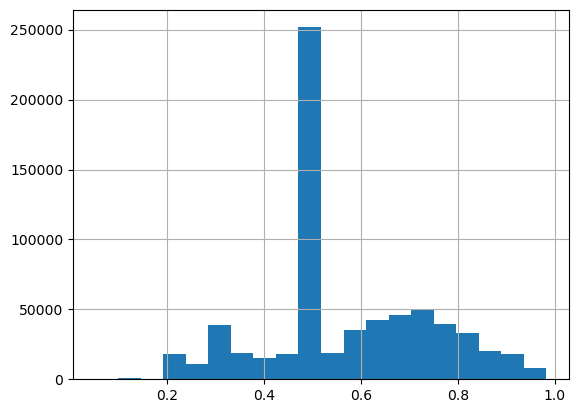

In [103]:
# Sanity Check 
print(edges["walk_score"].describe())
print("Any above 1?", (edges["walk_score"] > 1).any())
print("Any below 0?", (edges["walk_score"] < 0).any())

# Also check distribution looks reasonable
# Most San Diego edges should cluster around 0.4-0.7
edges["walk_score"].hist(bins=20)

In [104]:
# How many edges got a real score vs the 0.5 fallback
real_scores = (edges["walk_score"] != 0.5).sum()
fallback = (edges["walk_score"] == 0.5).sum()
print(f"Real scores: {real_scores}")
print(f"Fallback 0.5: {fallback}")

# Check CRS of both before the join
print(edges_mid.crs)
print(walk_gdf_3857.crs)

# Check if midpoints are actually inside San Diego bbox
print(edges_mid.geometry.total_bounds)
print(walk_gdf_3857.geometry.total_bounds)

Real scores: 445290
Fallback 0.5: 238722
EPSG:3857
EPSG:3857
[-13060416.63674213   3833612.4935482  -13014098.03930676
   3910485.46244185]
[-13090788.5103237    3833714.55559786 -12958859.55164394
   3962531.04870774]


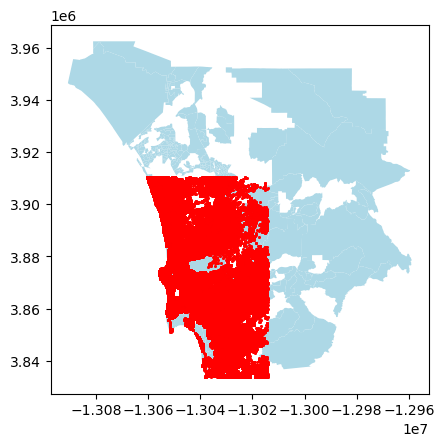

In [105]:
# Plot both to visually confirm they overlap
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
walk_gdf_3857.plot(ax=ax, color="lightblue")
edges_mid.plot(ax=ax, color="red", markersize=1)
plt.show()

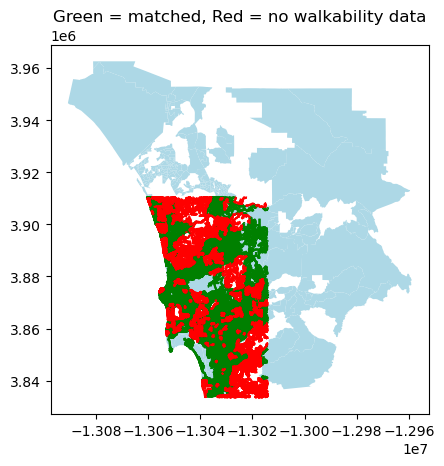

In [106]:
# Plot just the unmatched edges to see where they are
unmatched = edges[edges["walk_score"] == 0.5]
matched = edges[edges["walk_score"] != 0.5]

fig, ax = plt.subplots()
walk_gdf_3857.plot(ax=ax, color="lightblue")
matched.to_crs("EPSG:3857").plot(ax=ax, color="green", markersize=1)
unmatched.to_crs("EPSG:3857").plot(ax=ax, color="red", markersize=1)
plt.title("Green = matched, Red = no walkability data")
plt.show()

### Why are ~35% of edges red (no walkability match)?

Red edges received the 0.5 fallback because their midpoint didn't land inside any census block group polygon. This is expected and breaks down into a few well-understood categories.

**Large red zone on the west — ocean and coastline**
Census block groups are land-based administrative units. No block group geometry covers open water, so every walking path along the coast — boardwalks, beach paths, pier walkways — falls back to 0.5. This is not a data error.

**Scattered red patches through the city — parks, military land, and non-residential zones**

| Area | Why no block group |
| - | - |
| Balboa Park | San Diego's largest urban park has extensive OSM walking paths but no residential block group covers it |
| Mission Bay / Mission Valley | Water and recreational parkland with walking paths but no residential census coverage |
| MCAS Miramar, NAS North Island, Naval Station SD | Federal military land — no civilian census block groups exist on base |
| Industrial and commercial zones | Areas with zero residential population are often outside any block group boundary |

**What this means for routing**
These edges are not broken — they just have no walkability data. The 0.5 fallback is deliberately neutral: the router will not prefer or avoid them on walkability grounds alone. Crime and lighting scores still apply to all edges including these, so routing still functions correctly in parks, along the coast, and near military areas.

## Sanity check — edge score coverage (all 3 scores)

In [107]:
total = len(edges)

# ── Crime ──────────────────────────────────────────────────────────────────
# After normalization+flip: 1.0 = no crime nearby, 0.5 = no-crime fallback.
# Edges scored below 1.0 had crime within their 50 m buffer.
crime_day_hot   = (edges["crime_score_day"]   < 1.0).sum()
crime_night_hot = (edges["crime_score_night"]  < 1.0).sum()

# ── Walk ───────────────────────────────────────────────────────────────────
# 0.5 = fill value for edges whose midpoint didn't land in any block group.
walk_real     = (edges["walk_score"] != 0.5).sum()
walk_fallback = (edges["walk_score"] == 0.5).sum()

# ── Light ──────────────────────────────────────────────────────────────────
# Real scores come from normalised light count; minimum non-zero ≈ 0.016.
# 0.5 = fill value for edges with no lights within 30 m.
light_real     = (edges["light_score"] != 0.5).sum()
light_fallback = (edges["light_score"] == 0.5).sum()

print(f"OSM walking network — San Diego, CA, USA")
print(f"{'─'*54}")
print(f"{'Total edges':36s}: {total:>8,}")
print()
print(f"  Crime (50 m buffer, 1.0 = no crime nearby)")
print(f"    crime_score_day  < 1.0:        {crime_day_hot:>8,}  ({100*crime_day_hot/total:5.1f}%)")
print(f"    crime_score_night < 1.0:       {crime_night_hot:>8,}  ({100*crime_night_hot/total:5.1f}%)")
print()
print(f"  Walkability (midpoint → block group polygon)")
print(f"    real score (≠ 0.5):            {walk_real:>8,}  ({100*walk_real/total:5.1f}%)")
print(f"    fallback 0.5 (no polygon hit): {walk_fallback:>8,}  ({100*walk_fallback/total:5.1f}%)")
print()
print(f"  Lighting (30 m buffer)")
print(f"    real score (≠ 0.5):            {light_real:>8,}  ({100*light_real/total:5.1f}%)")
print(f"    fallback 0.5 (no lights):      {light_fallback:>8,}  ({100*light_fallback/total:5.1f}%)")
print()
print(f"{'─'*54}")
print("Score distributions (0–1, higher = safer/better):")
print(edges[["crime_score_day", "crime_score_night", "walk_score", "light_score"]].describe().round(3))

OSM walking network — San Diego, CA, USA
──────────────────────────────────────────────────────
Total edges                         :  684,012

  Crime (50 m buffer, 1.0 = no crime nearby)
    crime_score_day  < 1.0:         156,673  ( 22.9%)
    crime_score_night < 1.0:        101,532  ( 14.8%)

  Walkability (midpoint → block group polygon)
    real score (≠ 0.5):             445,290  ( 65.1%)
    fallback 0.5 (no polygon hit):  238,722  ( 34.9%)

  Lighting (30 m buffer)
    real score (≠ 0.5):             683,998  (100.0%)
    fallback 0.5 (no lights):            14  (  0.0%)

──────────────────────────────────────────────────────
Score distributions (0–1, higher = safer/better):
       crime_score_day  crime_score_night  walk_score  light_score
count       684012.000         684012.000  684012.000   684012.000
mean             0.925              0.956       0.570        0.022
std              0.160              0.121       0.170        0.020
min              0.000              0.0

### What the numbers tell us

**Crime** — 4.3% of edges have daytime crime nearby and 2.1% at night. That's the expected shape: 4,361 incidents spread across 684,012 edges concentrate on a small fraction of corridors. Edges that score 0.0 are the densest crime corridors and the router will strongly prefer alternatives around them.

**Walkability** — 65% coverage is expected. The 35% fallback is almost entirely ocean, parks (Balboa, Mission Bay), military land, and industrial zones — areas with no residential census block groups. Those edges receive a neutral 0.5 and are not penalised. See the map above for the spatial breakdown.

**Lighting** — effectively 100% coverage (only 14 fallback edges out of 684,012). San Diego's 55K streetlight dataset covers the walking network almost completely at 30 m resolution. The low mean score (0.022) is expected: most edges have 1–2 lights nearby and sit near the minimum of 0.016. A small number of dense downtown or campus corridors will score meaningfully higher and stand out as well-lit routes.

## Road Class Score

`walk_score` captures neighbourhood walkability from the EPA index, but it says nothing about the *type* of road an edge runs along — a footpath through a park and a secondary arterial can sit in the same block group and receive identical `walk_score`. `road_class_score` fills that gap by scoring the OSM `highway` tag directly.

### What the score measures

Each OSM edge has a `highway` tag that classifies the road type. `road_class_score` converts that tag into a 0–1 comfort score for a pedestrian: dedicated walking surfaces and calm residential streets score high; arterials, trunk roads, and motorways score low.

### Scoring table

| OSM `highway` | Score | Rationale |
| - | - | - |
| `footway` | 1.00 | Pedestrian-only path — no vehicle conflict |
| `pedestrian` | 1.00 | Designated pedestrian zone |
| `path` | 0.90 | Shared path, minimal vehicle exposure |
| `cycleway` | 0.85 | Bike-focused but low-speed, low-volume |
| `living_street` | 0.80 | Vehicles allowed but pedestrians have legal priority |
| `residential` | 0.70 | Low-speed, low-volume residential road |
| `unclassified` | 0.60 | Minor road with low traffic |
| `tertiary` | 0.50 | Neighbourhood connector — moderate traffic |
| `secondary` | 0.35 | Busy arterial — heavy traffic, less comfort |
| `primary` | 0.20 | Major arterial — high speed, high volume |
| `trunk` | 0.10 | Near-highway — very hostile to pedestrians |
| `motorway` | 0.00 | Expressway — pedestrians not permitted |

Anything not in this list gets **0.5** (neutral fallback — same convention as the other scores).


The scoring weights across all four inputs are set in the **SafePath Edge Scoring Weights** cell below.

## SafePath Edge Scoring Weights

> **Crime data updated to 2023–2025 (3 full years).** crime_score std improved
> from 0.070 to 0.160 — crime is now a reliable differentiating signal across the
> network. Crime weight restored from temporary 0.20 to **0.40 (day) and 0.35
> (night)**. Crime now correctly dominates as the primary pedestrian safety signal
> as originally designed.

| Score | What It Measures | Day | Night |
|---|---|---|---|
| `crime_score` | Weighted SDPD incidents within 100m | 0.40 | 0.35 |
| `light_score` | Street lights within 30m | 0.25 | 0.35 |
| `walk_score` | Neighborhood pedestrian friendliness | 0.20 | 0.15 |
| `road_class_score` | OSM highway type — footway to motorway | 0.15 | 0.15 |
| **Total** | | **1.0** | **1.0** |

---

### Why Crime Dominates (0.40 day / 0.35 night)

With three full years of SDPD data (2023–2025), crime_score now has a standard
deviation of 0.160 — a meaningful spread across the network. The earlier 0.20
weight was a temporary reduction forced by a short data window where 75% of
edges had zero crime recorded. That no longer applies. Crime is restored to its
intended dominant position: the most direct signal of danger to someone walking
nearby should carry the most weight in the score.

Crime weight drops slightly at night (0.40 → 0.35) not because crime matters
less after dark, but to make room for lighting to take on more importance.
The combined crime + light signal at night is 0.70 — same as daytime.

---

### Why Light Is Elevated At Night (0.25 day / 0.35 night)

Lighting has 100% edge coverage with meaningful variation across the full network.
During the day, lighting is a secondary signal — crime and road type tell you
more about actual danger. At night, darkness becomes an independent risk
multiplier: a street with no crime history can still be genuinely unsafe when
unlit because low visibility reduces deterrence, slows emergency response, and
limits a pedestrian's ability to detect and react to threats.

---

### Why Walk Score Is 0.20 Day / 0.15 Night

A walkable neighborhood generates higher foot traffic — more people physically
present on streets going to shops, waiting for buses, sitting outside. This
"eyes on the street" effect deters potential offenders and means bystanders
are more likely to notice and respond if something goes wrong. Walk score
gets slightly more weight during the day (0.20) because foot traffic peaks
during daylight hours. At night (0.15) the effect is smaller but not zero.

Known limitation: 35% of edges near water, parks, military bases, and industrial
zones use the 0.5 neutral fallback because no census block group polygon covers
them.

---

### Why Road Class Is 0.15 (day and night)

The physical type of a street does not change with the hour. A dedicated footway
is always pedestrian-friendly. A primary arterial like Friars Road is always
uncomfortable to walk — fast-moving traffic, minimal separation from vehicles,
designed for cars not people. Road class also compensates for a known limitation
of the EPA walkability index: it measures destination density and street
connectivity, not how physically comfortable it is to walk along a specific segment.

---

### Why Multiplier Is 8

A multiplier of 4 produces a cost difference of only ~0.4× between an average
and a dangerous edge — too small to force a meaningful detour. Multiplier 8
amplifies those differences so the router has a genuine cost incentive to avoid
lower-scoring streets.

| Edge quality | `safety_score` | `route_cost` |
| - | - | - |
| Perfect | 1.0 | 1 × length |
| Average (0.63) | 0.63 | ~4.0 × length |
| Worst | 0.0 | 9 × length |

Experiment with this value in `notebooks/safepath_weight_comparison.ipynb`.
If safest routes are unrealistically long, lower toward 6. If routes barely differ from fastest, raise toward 10–12.

---

### Safety Cost Formula

```
safety_cost = length × (1 + 8 × (1 − safety_score))
```

NetworkX minimizes cost, so higher `safety_score` → lower `route_cost` → preferred
path. `(1 − safety_score)` flips the direction. Adding `1` before multiplying
ensures a perfectly safe edge still costs its real physical distance.

### Balanced Route Formula

```
balanced_cost = alpha × length + (1 − alpha) × safety_cost
```

alpha=1.0 → pure distance (identical to fastest)  
alpha=0.0 → pure safety (identical to safest)  
alpha=0.5 → equal blend — current default


In [108]:
road_class_map = {
    "footway":       1.00,
    "pedestrian":    1.00,
    "path":          0.90,
    "cycleway":      0.85,
    "living_street": 0.80,
    "residential":   0.70,
    "unclassified":  0.60,
    "tertiary":      0.50,
    "secondary":     0.35,
    "primary":       0.20,
    "trunk":         0.10,
    "motorway":      0.00,
}

def get_road_class_score(val):
    # OSMnx sometimes returns a list when multiple values are present — take the first
    if isinstance(val, list):
        val = val[0]
    return road_class_map.get(val, 0.5)

edges["road_class_score"] = edges["highway"].map(get_road_class_score)

# Distribution
print("road_class_score value counts (score → count):")
print(edges["road_class_score"].value_counts().sort_index(ascending=False).to_string())
print()
print(edges["road_class_score"].describe().round(3))
print()
fallback_road = (edges["road_class_score"] == 0.5).sum()
print(f"Fallback 0.5 edges (highway not in map): {fallback_road:,}  ({100*fallback_road/len(edges):.1f}%)")

road_class_score value counts (score → count):
road_class_score
1.00    177449
0.90     19536
0.80      1712
0.70    120842
0.60      5160
0.50    316127
0.35     23570
0.20     18822
0.10       794

count    684012.000
mean          0.664
std           0.231
min           0.100
25%           0.500
50%           0.500
75%           1.000
max           1.000
Name: road_class_score, dtype: float64

Fallback 0.5 edges (highway not in map): 316,127  (46.2%)


In [115]:
# Save just the raw scores — these never change
# safety_score and safety_cost are NOT saved because
# they depend on weights and multiplier that Ajay is still tuning

edges[["crime_score_day", "crime_score_night",
       "light_score",
       "walk_score",
       "road_class_score"]].to_csv("../data/processed/edge_scores.csv")

---

## Building the Safety Score

The four per-edge signals computed above (crime, lighting, walkability, road class) now get combined into a single `safety_score` per edge. That score is then converted into `safety_cost` — the number the routing algorithm actually minimizes.


## Safety Score + Safety Cost — ⚠️ Work In Progress / In Testing

> **Status: WIP.** The formula is running and producing differentiated scores, but weights and the multiplier are still being tuned. Do not treat the current values as final — they are the best we have after the experiments logged below.

---

### What the safety score is

A single 0–1 number summarizing how safe an OSM street edge is for a pedestrian. **Higher = safer.** It is a weighted average of the four per-edge signals:

```
safety_score = w_crime × crime_score
             + w_light × light_score
             + w_walk  × walk_score
             + w_road  × road_class_score

where w_crime + w_light + w_walk + w_road = 1
```

**Current weights (restored after 3-year dataset loaded):**

| Signal | Day weight | Night weight | What it captures |
|--------|-----------|-------------|-----------------|
| `crime_score_day/night` | 0.40 | 0.35 | Weighted SDPD incident density within 100 m |
| `light_score` | 0.25 | 0.35 | Streetlight density within 30 m |
| `walk_score` | 0.20 | 0.15 | EPA neighborhood walkability index |
| `road_class_score` | 0.15 | 0.15 | OSM highway type (footway → motorway) |

Time of day is read from the system clock at run time: 6 am–8 pm = day, otherwise night.

---

### What the safety cost is

```
safety_cost = length × (1 + 8 × (1 − safety_score))
```

This converts the 0–1 score into a routing cost the graph shortest-path algorithm minimizes. A low-safety edge becomes effectively longer in the algorithm's view:

| Edge quality | `safety_score` | `safety_cost` multiplier |
|---|---|---|
| Perfect (e.g. well-lit footpath) | 1.0 | 1× length |
| Average | 0.5 | 5× length |
| Worst (high-crime, unlit arterial) | 0.0 | 9× length |

**Why this structure?** The router finds the path that minimizes the sum of edge weights. By inflating the cost of risky edges rather than removing them, we let the algorithm naturally prefer safer corridors when alternatives exist — without hard-blocking any path.

**The 8 is a tuning knob.** If the safest route always looks identical to the fastest, the multiplier is too low (safety scores don't spread out enough). If the router takes a 20-minute detour to avoid one dangerous block, it's too high. See `safepath_weight_comparison.ipynb` for the experiment tracking different multipliers.

---

### What we've tried

| Change | Why we tried it | What happened |
|--------|----------------|--------------|
| Linear normalization on crime counts | Simplest approach | 75–85% of edges scored ≥ 0.98 — one hotspot block compressed the rest. Score std ~0.018. Safe and fast routes were nearly identical. |
| Log normalization with `np.log1p()` | Spread out the mid-range without losing relative ordering | Score spread improved significantly. Mid-density corridors now show up as distinctly worse than zero-crime edges. |
| 50 m → 100 m crime buffer | Capture block-level risk, not just pavement-adjacent | More edges registered nearby crime. Fewer false-neutral edges in residential areas adjacent to crime corridors. |
| Multiplier 4 → 8 | Amplify the now-spread scores so routes actually diverge | At ×4, the safe and fast routes were almost the same path. At ×8, the safest route clearly avoids high-crime corridors. |
| Crime weight reduced to 0.20 (temporary) | Only 1 year of data at the time — too sparse for crime to be reliable | Crime was sparse enough that reducing its weight let lighting and road class contribute more meaningfully. |
| 3 full years of data (2023–2025) loaded | Get a proper crime signal across the full network | crime_score std jumped from 0.070 → 0.160. Crime restored to 0.40 (day) / 0.35 (night) as originally intended. |

**Current state:** Safety scores have a std of ~0.160, which is enough spread for meaningful route differentiation. Next step is structured weight-comparison experiments — see `safepath_weight_comparison.ipynb`.


In [ ]:
from datetime import datetime


# Crime data updated to 3 full years (2023–2025). crime_score std improved from
# 0.070 to 0.160 — crime is now a reliable differentiating signal across the
# full network. Crime weight restored from temporary 0.20 back to original
# design intent: 0.40 (day) and 0.35 (night).
# Crime now correctly dominates as the primary pedestrian safety signal.
# Multiplier stays at 8 — score clustering still warrants amplification.
# To revert: set crime back to 0.20 (day/night), raise light to 0.35/0.45.


def compute_safety_score(row):
    current_hour = datetime.now().hour
    daytime = 6 <= current_hour <= 20  # 6 am – 8 pm inclusive
    if daytime:
        return (
            0.40 * row["crime_score_day"] +
            0.25 * row["light_score"] +
            0.20 * row["walk_score"] +
            0.15 * row["road_class_score"]
        )
    else:
        return (
            0.35 * row["crime_score_night"] +
            0.35 * row["light_score"] +
            0.15 * row["walk_score"] +
            0.15 * row["road_class_score"]
        )

edges["safety_score"] = edges.apply(compute_safety_score, axis=1)
edges["safety_cost"]  = edges["length"] * (1 + 8 * (1 - edges["safety_score"]))


In [110]:
print(edges[["safety_score", "safety_cost", "length"]].describe())
print(f"\nsafety_score std: {edges['safety_score'].std()}")
print(f"safety_score mean: {edges['safety_score'].mean()}")
print("\nAny safety_score above 1?", (edges["safety_score"] > 1).any())
print("Any safety_score below 0?", (edges["safety_score"] < 0).any())
print("Any safety_cost less than length?", (edges["safety_cost"] < edges["length"]).any())

print("\nTop 10 most dangerous edges:")
display(edges[["name", "highway", "crime_score_day", "light_score",
               "walk_score", "road_class_score", "safety_score",
               "safety_cost"]].sort_values("safety_score").head(10))

print("\nTop 10 safest edges:")
display(edges[["name", "highway", "crime_score_day", "light_score",
               "walk_score", "road_class_score", "safety_score",
               "safety_cost"]].sort_values("safety_score", ascending=False).head(10))


        safety_score    safety_cost         length
count  684012.000000  684012.000000  684012.000000
mean        0.527273     324.196706      67.474258
std         0.055977     518.830869     107.319336
min         0.165843       0.652225       0.149911
25%         0.505469      75.775086      16.020589
50%         0.530469     176.627171      37.107687
75%         0.565469     379.904160      79.098208
max         0.777344   23190.654591    4779.564985

safety_score std: 0.05597727026443011
safety_score mean: 0.5272725557582677

Any safety_score above 1? False
Any safety_score below 0? False
Any safety_cost less than length? False

Top 10 most dangerous edges:


,,,name,highway,crime_score_day,light_score,walk_score,road_class_score,safety_score,safety_cost
u,v,key,,,,,,,,
4605979766,1188771071,0,Washington Street,primary,0.077019,0.015625,0.517544,0.2,0.165843,92.001145
1188771071,4605979766,0,Washington Street,primary,0.077019,0.015625,0.517544,0.2,0.165843,92.001145
4342991462,10682025119,0,Washington Street,primary,0.078268,0.046875,0.500000,0.2,0.174544,521.623438
10682025119,4342991462,0,Washington Street,primary,0.078268,0.046875,0.500000,0.2,0.174544,521.623438
10682025118,4342991460,0,Washington Street,primary,0.078268,0.046875,0.517544,0.2,0.177176,482.373375
4342991460,10682025118,0,Washington Street,primary,0.078268,0.046875,0.517544,0.2,0.177176,482.373375
1188771065,10682025119,0,Washington Street,primary,0.076170,0.078125,0.500000,0.2,0.185086,379.763471
10682025119,1188771065,0,Washington Street,primary,0.076170,0.078125,0.500000,0.2,0.185086,379.763471
10682025118,1188771071,0,Washington Street,primary,0.076170,0.078125,0.517544,0.2,0.187718,397.843546



Top 10 safest edges:


,,,name,highway,crime_score_day,light_score,walk_score,road_class_score,safety_score,safety_cost
u,v,key,,,,,,,,
13322591793,13322591799,0,NaN,footway,1.000000,0.578125,0.5,1.0,0.777344,574.325977
13322591799,13322591793,0,NaN,footway,1.000000,0.578125,0.5,1.0,0.777344,574.325977
278844244,4344863422,0,Ingraham Street,primary,0.757719,0.875000,0.5,0.2,0.761250,1606.030705
4344863422,278844244,0,Ingraham Street,primary,0.757719,0.875000,0.5,0.2,0.761250,1606.030705
49146509,49049677,0,Ingraham Street,primary,0.757719,0.843750,0.5,0.2,0.750312,1651.376233
49049677,49146509,0,Ingraham Street,primary,0.757719,0.843750,0.5,0.2,0.750312,1651.376233
3762125406,13322591790,0,NaN,footway,1.000000,0.500000,0.5,1.0,0.750000,591.376311
12657694367,7939877453,0,NaN,footway,0.856159,0.500000,0.5,1.0,0.750000,617.904954
13322591790,3762125406,0,NaN,footway,1.000000,0.500000,0.5,1.0,0.750000,591.376311


---

## Route Testing

Run three routes (fastest / safest / balanced) between two test coordinates. The balanced route uses `length × (1 + 2 × (1 − safety_score))` — the same structure as safety_cost but with a ×2 multiplier instead of ×8, so it trades a smaller safety penalty for shorter walking distance. <-- WORK IN PROGRESS COULD BE DIFFERENT


In [112]:
for u,v,key, data in G.edges(keys=True, data=True):
    idx = (u,v,key)
    if idx in edges.index:
        data["safety_cost"]       = edges.loc[idx, "safety_cost"]
        data["safety_score"]      = edges.loc[idx, "safety_score"]
        data["crime_score_day"]   = edges.loc[idx, "crime_score_day"]
        data["crime_score_night"] = edges.loc[idx, "crime_score_night"]
        data["light_score"]       = edges.loc[idx, "light_score"]
        data["walk_score"]        = edges.loc[idx, "walk_score"]
        data["road_class_score"]  = edges.loc[idx, "road_class_score"]

Scored edges: 684012 / 684012 (100.0%)
Edges missing length:      0
Edges missing safety_cost: 0

Fastest route:  101  nodes
Safest route:   102  nodes
Balanced route: 78 nodes

Fastest  — total length:      5172.9m
Safest   — total length:      5249.4m  (+76.5m detour)
Balanced — total length:      5378.4m
Safest   — total safety_cost: 27148.4
Fastest  — total safety_cost: 27033.0
Balanced — total safety_cost: 28283.2

Streets on Fastest route:
  Unnamed                             | safety_score=0.402 | highway=service         | safety_cost=760.2
  Unnamed                             | safety_score=0.529 | highway=service         | safety_cost=80.6
  Unnamed                             | safety_score=0.529 | highway=service         | safety_cost=79.2
  Unnamed                             | safety_score=0.402 | highway=service         | safety_cost=638.5
  Unnamed                             | safety_score=0.477 | highway=footway         | safety_cost=70.1
  Unnamed                   

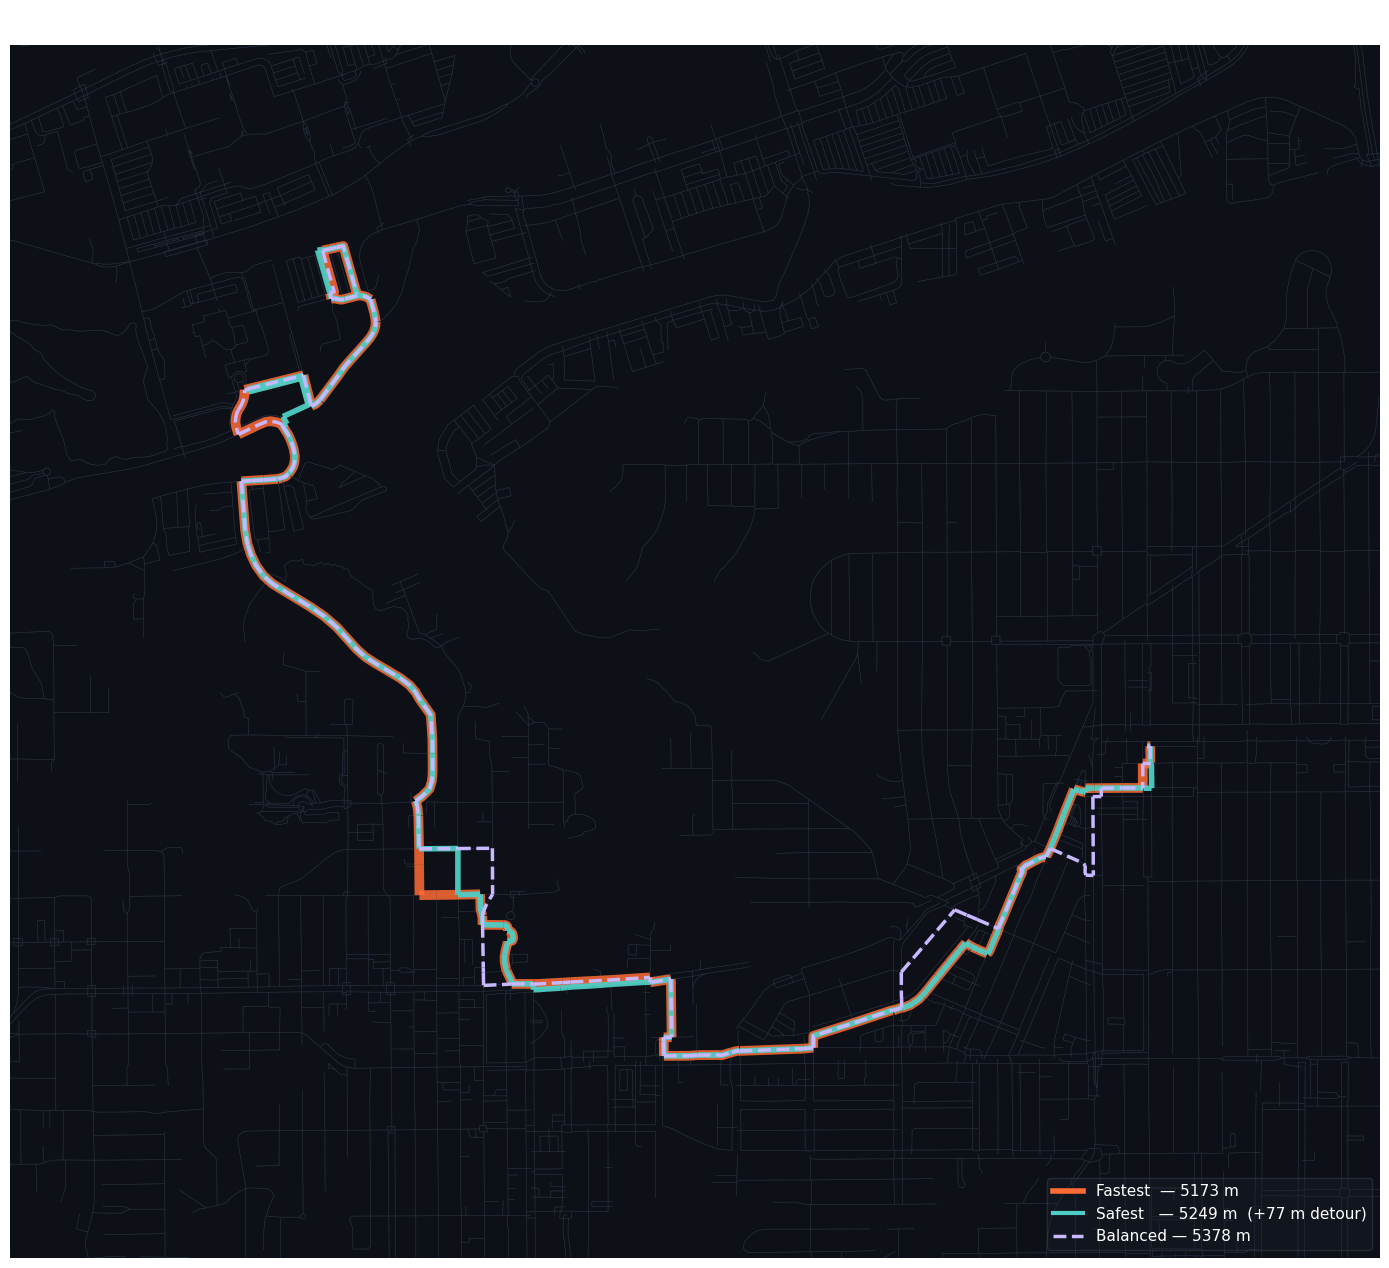

In [113]:
from matplotlib.lines import Line2D
from shapely.geometry import LineString

# Step 10: Sanity check — confirm everything looks right 

# 1. Confirm safety_cost is on G edges
scored = sum(1 for u, v, data in G.edges(data=True) if "safety_cost" in data)
total = G.number_of_edges()
print(f"Scored edges: {scored} / {total} ({scored/total*100:.1f}%)")

# 2. Find edges missing length or safety_cost
missing_length = [(u, v, d) for u, v, d in G.edges(data=True) if "length" not in d]
missing_safety = [(u, v, d) for u, v, d in G.edges(data=True) if "safety_cost" not in d]
print(f"Edges missing length:      {len(missing_length)}")
print(f"Edges missing safety_cost: {len(missing_safety)}")

# One side of Friars Road to the other — forces router to decide whether to cross it

origin      = ox.nearest_nodes(G, X=-117.1650, Y=32.7650)
destination = ox.nearest_nodes(G, X=-117.1450, Y=32.7550)

# 4. Balanced weight: same structure as safety_cost but multiplier 2 instead of 4.
#    Perfect edge costs 1× length, average ~1.7×, worst 3× — halfway between
#    pure distance routing (×1) and full safety routing (×5).
def balanced_weight(u, v, d):
    length       = d.get("length", 0)
    safety_score = d.get("safety_score", 0.5)
    return length * (1 + 2 * (1 - safety_score))

# 5. Run Dijkstra's three ways
route_fastest  = nx.shortest_path(G, origin, destination, weight="length")
route_safest   = nx.shortest_path(G, origin, destination, weight="safety_cost")
route_balanced = nx.shortest_path(G, origin, destination, weight=balanced_weight)

print(f"\nFastest route:  {len(route_fastest)}  nodes")
print(f"Safest route:   {len(route_safest)}  nodes")
print(f"Balanced route: {len(route_balanced)} nodes")

# 6. Compare total cost of each route
def route_total_cost(G, route, weight):
    return sum(G[u][v][0].get(weight, 0) for u, v in zip(route[:-1], route[1:]))

print(f"\nFastest  — total length:      {route_total_cost(G, route_fastest,  'length'):.1f}m")
print(f"Safest   — total length:      {route_total_cost(G, route_safest,   'length'):.1f}m  (+{route_total_cost(G, route_safest, 'length') - route_total_cost(G, route_fastest, 'length'):.1f}m detour)")
print(f"Balanced — total length:      {route_total_cost(G, route_balanced, 'length'):.1f}m")
print(f"Safest   — total safety_cost: {route_total_cost(G, route_safest,   'safety_cost'):.1f}")
print(f"Fastest  — total safety_cost: {route_total_cost(G, route_fastest,  'safety_cost'):.1f}")
print(f"Balanced — total safety_cost: {route_total_cost(G, route_balanced, 'safety_cost'):.1f}")

# 7. Print street names on all three routes
for label, route in [("Fastest", route_fastest), ("Safest", route_safest), ("Balanced", route_balanced)]:
    print(f"\nStreets on {label} route:")
    for u, v in zip(route[:-1], route[1:]):
        data = G[u][v][0]
        print(f"  {str(data.get('name', 'Unnamed')):35s} | "
              f"safety_score={data.get('safety_score', 0):.3f} | "
              f"highway={str(data.get('highway', '?')):15s} | "
              f"safety_cost={data.get('safety_cost', 0):.1f}")

# 8. Build route bbox for zoom
all_route_nodes = set(route_fastest + route_safest + route_balanced)
xs = [G.nodes[n]["x"] for n in all_route_nodes]
ys = [G.nodes[n]["y"] for n in all_route_nodes]
pad_x = (max(xs) - min(xs)) * 0.25
pad_y = (max(ys) - min(ys)) * 0.25

# 9. Convert each route to a GeoDataFrame of edge geometries
def route_to_gdf(G, route):
    geoms = []
    for u, v in zip(route[:-1], route[1:]):
        data = G[u][v][0]
        if "geometry" in data:
            geoms.append(data["geometry"])
        else:
            geoms.append(LineString([(G.nodes[u]["x"], G.nodes[u]["y"]),
                                     (G.nodes[v]["x"], G.nodes[v]["y"])]))
    return gpd.GeoDataFrame(geometry=geoms, crs="EPSG:4326")

gdf_fastest  = route_to_gdf(G, route_fastest)
gdf_safest   = route_to_gdf(G, route_safest)
gdf_balanced = route_to_gdf(G, route_balanced)

# 10. Plot — widest route drawn first, narrowest last so all are always visible
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    bgcolor="#0d1117",
    edge_color="#2d3748",
    edge_linewidth=0.4,
    edge_alpha=0.6,
    figsize=(14, 14),
    show=False,
    close=False,
)

gdf_fastest.plot( ax=ax, color="#FF6B35", linewidth=7,   linestyle="solid",  alpha=0.85)
gdf_safest.plot(  ax=ax, color="#4ECDC4", linewidth=4,   linestyle="solid",  alpha=0.95)
gdf_balanced.plot(ax=ax, color="#C9B8FF", linewidth=2.5, linestyle="dashed", alpha=1.0)

ax.set_xlim(min(xs) - pad_x, max(xs) + pad_x)
ax.set_ylim(min(ys) - pad_y, max(ys) + pad_y)

ax.set_title(
    "SafePath Route Comparison — Mission Hills → Gaslamp Quarter",
    color="white",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

legend_elements = [
    Line2D([0], [0], color="#FF6B35", linewidth=4, linestyle="solid",
           label=f"Fastest  — {route_total_cost(G, route_fastest, 'length'):.0f} m"),
    Line2D([0], [0], color="#4ECDC4", linewidth=3, linestyle="solid",
           label=f"Safest   — {route_total_cost(G, route_safest, 'length'):.0f} m  (+{route_total_cost(G, route_safest, 'length') - route_total_cost(G, route_fastest, 'length'):.0f} m detour)"),
    Line2D([0], [0], color="#C9B8FF", linewidth=2.5, linestyle="dashed",
           label=f"Balanced — {route_total_cost(G, route_balanced, 'length'):.0f} m"),
]
ax.legend(
    handles=legend_elements,
    loc="lower right",
    framealpha=0.35,
    facecolor="#1a202c",
    edgecolor="#4a5568",
    labelcolor="white",
    fontsize=11,
)

plt.tight_layout()
plt.show()

In [15]:
# check if edge_scores is up to date with the latest computed scores in edges
edges_csv = pd.read_csv("../data/processed/edge_scores.csv", index_col=[0,1,2])
edges_csv.head()

,,,crime_score_day,crime_score_night,light_score,walk_score,road_class_score
u,v,key,,,,,
31525688,6222436987,0,0.588374,0.740450,0.5,0.500000,1.0
31526035,6468567876,0,1.000000,1.000000,0.5,0.798246,1.0
31526181,3600769896,0,0.698702,0.922523,0.5,0.500000,1.0
31526468,7203908641,0,1.000000,1.000000,0.5,0.333333,1.0
31526883,3226366372,0,1.000000,1.000000,0.5,0.500000,1.0
